# RLSSM Simulators: A Beginner's Tutorial

This tutorial is a gentle, end-to-end introduction to the **reinforcement-learning
sequential sampling model (RLSSM)** simulator in `ssm-simulators`, exposed through the
`ssms.rl` namespace.

The intended reader is someone who wants to simulate learning-and-decision behavior,
but may not already know the reinforcement-learning (RL), sequential-sampling model
(SSM), or HSSM vocabulary. We will keep the math light, explain each modeling block,
and use small plots to connect the concepts to the generated data.

By the end you will be able to:

1. Understand what an RLSSM *is*, what it is useful for, and the three pieces it is built from.
2. Discover a built-in model (a **preset**) and simulate behavioral data from it.
3. Compose your own model from a learning rule, a decision process, and a task.
4. Simulate many participants and inspect / visualize the generated data.
5. See how learned Q-values become trial-wise decision-process parameters.
6. Validate a dataset and understand how it hands off to **HSSM** for inference.

> **This is the basic tutorial — the lay of the land.** It sticks to the single most
> common path. Topics such as custom components, response/choice mapping, context-aware
> learning, posterior predictive (PPC) simulation, assembled models, backend/gradient
> control, and multi-parameter handshakes are covered in the
> [advanced tutorial](rlssm_advanced_tutorial.ipynb).


## What is an RLSSM?

A **reinforcement-learning (RL)** model describes how an agent learns from experience.
On each trial, the agent chooses an action, receives feedback, and updates internal
value estimates. In a two-armed bandit task, those value estimates are often called
**Q-values**: one value for each arm/action. A high Q-value means "this action has been
rewarding so far."

A **sequential sampling model (SSM)** — like the drift-diffusion model (DDM) or the
angle model — describes *how a single decision unfolds in time*. Noisy evidence
accumulates until it crosses a boundary, producing both a **choice** and a **response
time (RT)**. SSMs are useful because two people can make the same choices for different
latent reasons: one may accumulate evidence quickly, another may set a more cautious
boundary, and both patterns can show up in the RT distribution.

An **RLSSM** combines these ideas. The RL part tracks how values change *across trials*;
the SSM part describes the choice and RT generated *within each trial*. This lets the
model explain not only whether choices improve with feedback, but also how learning
changes decision speed, caution, or evidence strength over time.

| Pillar | What it does | Example in this tutorial |
|--------|--------------|--------------------------|
| **Learning process** | Updates internal state from trial context, such as choices and feedback | Rescorla-Wagner delta rule (learns Q-values) |
| **Decision process** | An SSM that turns current trial-wise parameters into a choice + RT | Angle model |
| **Task environment** | Delivers choices, feedback, and other per-trial context | Two-armed Bernoulli bandit |

In this tutorial, the learning process computes a trial-wise **drift rate** for the
angle SSM. Intuitively, drift is the momentary pull toward one response boundary or the
other. When the learned value difference is large, the decision process receives a
stronger drift signal; when the learned values are similar, the decision process is more
ambiguous.

The general `ssms.rl` contract is broader than this one preset: a learning, control, or
other sequential process can compute any subset of trial-wise decision-process
parameters, not only drift. The beginner path uses `v` because it is the easiest way to
see the RL-to-SSM connection.


### A conceptual picture from the RLDDM literature

The figure below shows a reinforcement-learning drift-diffusion model (RLDDM), one
well-known member of the broader RLSSM family. It is a useful map for this tutorial:
trial-wise Q-values determine a drift-rate-like decision parameter; the decision process
generates observed choice/RT data; feedback then updates Q-values for the next trial.

<figure style="text-align: center;">
    <img src="assets/rlssm.jpg" width="50%" alt="Graphical model of an RLSSM.">
    <figcaption>Graphical model of an RLSSM.</figcaption>
</figure>

*Figure reproduced from Fengler et al. (2026), "HSSM: A Widely Applicable Toolbox for Hierarchical Bayesian Neurocognitive Modeling". Article:
<https://doi.org/10.64898/2026.06.05.730398>.*



The exact notation in the paper is more detailed than we need here, but the core idea is
the same as `ssms.rl`: a learning state informs a decision process parameter, and the
resulting action/feedback pair determines the next learning state. A broader review of
why RL and SSMs are complementary is Miletić, Boag, and Forstmann (2020):
<https://doi.org/10.1016/j.neuropsychologia.2019.107261>.


### The interleaved simulation loop

Because the parameters change with experience, RLSSM simulation is **not** a single
fixed-parameter draw. It is an interleaved loop, repeated for every trial:

1. **Start from the current learning state.** In this tutorial that state is two
   Q-values, `Q[0]` and `Q[1]`, one for each bandit arm.
2. **Compute the trial-wise decision parameters.** The Rescorla-Wagner learner produces
   drift via `v = (Q[1] - Q[0]) * scaler`. The `scaler` parameter converts a value
   difference into the numerical scale used by the decision process.
3. **Simulate one SSM trial.** The angle model uses drift plus fixed SSM parameters
   (`a`, `z`, `t`, `theta`) to generate a response and RT.
4. **Map response to learning choice.** The public response labels here are `-1` and
   `1`, but the learning rule updates zero-based choices `0` and `1`.
5. **Get context from the task environment.** The selected bandit arm returns a
   `feedback` value such as `0` or `1`. Other tasks could also provide fields such as
   `condition`, `block`, or `stimulus_id`.
6. **Update the learning state.** The prediction error is
   `feedback - Q[choice]`; the learning rate `rl_alpha` controls how strongly that
   error changes the selected Q-value.
7. **Repeat** with the new Q-values on the next trial.

One subtlety worth remembering: on each trial the **drift is computed *before* the
value update** for that trial. This ordering matches HSSM's inference-side computation,
which keeps simulation and inference consistent.


### Where this fits in the HSSM ecosystem

Two packages work as a pair:

- **`ssm-simulators` (this tutorial)** — *simulates* synthetic RLSSM behavioral data.
- **HSSM** — performs *Bayesian inference*, recovering parameters from such data.

So a typical workflow is: design a model and **simulate** data with `ssms.rl`, then
hand that data and model off to **HSSM** to fit it. Simulation is useful even before you
have empirical data: it lets you check whether the model behaves as expected, whether
plots show the learning pattern you intended, and whether HSSM can recover known
parameters from generated data. We end the tutorial by showing the handoff surface.


## 1. Setup

Everything we need lives under a single import. The convention is to alias the
namespace as `rl`. We also use pandas and matplotlib only for table inspection and
plots; they are not part of the simulator API.


In [1]:
import ssms.rl as rl

import pandas as pd
import matplotlib.pyplot as plt

## 2. The fastest path: presets

The quickest way to get going is a **preset** — a ready-made, validated model. A preset
is useful when you want to focus on learning the workflow before deciding every model
component yourself. The preset registry lets you discover what is available, inspect a
model's "spec card", and fetch a configuration to simulate from.


In [2]:
# Which presets ship with the package?
rl.preset.list()

['2AB_RW_Angle',
 '2AB_RW_DDM',
 '2AB_RW_DualAlpha_Angle',
 '2AB_RW_DualAlpha_InvTempSoftmax',
 '2AB_RW_InvTempSoftmax',
 '2AB_RW_Weibull',
 '3AB_RW_InvTempSoftmax',
 '4AB_RW_InvTempSoftmax',
 '4AB_RW_RaceNoBiasAngle']

Each preset has readable metadata. Printing `preset.info(...)` gives you a compact
"spec card": the task, the learning and decision processes, the parameters the model
needs, sensible defaults, and the response labels it emits.

In [3]:
print(rl.preset.info("2AB_RW_Angle"))

Preset: 2AB_RW_Angle
Description: Two-armed bandit with a Rescorla-Wagner delta-rule learner and an angle decision process.
Task: two-armed Bernoulli bandit
Learning process: RescorlaWagnerDrift
Decision process: angle
Required parameters: rl_alpha, scaler, a, z, t, theta
Default parameters: rl_alpha=0.2, scaler=2, a=1, z=0.5, t=0.001, theta=0
Response labels: (-1, 1)
Response to choice: {-1: 0, 1: 1}
Context fields: ['feedback']
Learning backend: jax
Gradient support: available
HSSM participant contract: yes


Reading the card top to bottom: `2AB_RW_Angle` is a **2**-**A**rmed **B**andit with a
**R**escorla–**W**agner learner and an **Angle** decision process. It needs six
parameters — two for learning (`rl_alpha`, `scaler`) and four for the angle SSM
(`a`, `z`, `t`, `theta`) — and it emits responses labeled `-1` and `1`.

Now fetch the configuration and build a simulator from it. The configuration describes
the model's **structure**; the actual parameter *values* are supplied separately as
`theta` when we call `simulate()`.

In [4]:
config = rl.preset.get("2AB_RW_Angle")
sim = rl.Simulator(config)

# Concrete parameter values for this run.
theta = {
    "rl_alpha": 0.3,  # learning rate
    "scaler": 2.0,  # maps learned value difference -> drift
    "a": 1.5,  # boundary separation (angle SSM)
    "z": 0.5,  # starting point
    "t": 0.3,  # non-decision time
    "theta": 0.2,  # boundary angle
}

data = sim.simulate(
    theta=theta,
    n_trials=120,
    n_participants=40,
    random_state=42,
)

data.head()

,participant_id,trial_id,rt,response,feedback
0,0,0,2.999996,1,0.0
1,0,1,1.506524,-1,0.0
2,0,2,1.080149,-1,0.0
3,0,3,1.355910,-1,1.0
4,0,4,1.051847,-1,0.0


The result is a tidy "long" DataFrame — one row per trial — ready for analysis or
inference. Its columns are:

- **`participant_id`** — which simulated participant (subject) the trial belongs to.
- **`trial_id`** — trial index *within* that participant, starting at `0`.
- **`rt`** — the simulated response time, in seconds.
- **`response`** — the choice, using the model's response labels (`-1` or `1` here).
- **`feedback`** — the task context field used by the learner for reward feedback.

Every participant has the same number of trials, in trial order: a **balanced panel**.
That balanced, participant-contiguous layout is the shape downstream HSSM inference
expects for the current RLSSM path. `trial_id` is ordinary useful data; the actual
learning replay follows row order within each participant.


## 3. Model anatomy: the three pillars

The preset we just used is an ordinary configuration object. Looking inside it makes
the three-pillar structure concrete — and shows where each parameter comes from. This
is a useful habit: before simulating or fitting a model, inspect which part of the model
owns each parameter.


In [5]:
print("Decision process    :", config.decision_process)
print("Learning process    :", type(config.learning_process).__name__)
print("Task environment    :", type(config.task_environment).__name__)
print("Computed SSM params :", config.learning_process.computed_params)
print("Context fields      :", config.context_fields)
print("Response -> choice  :", config.response_to_choice)
print("Free theta params   :", config.list_params)

Decision process    : angle
Learning process    : RescorlaWagnerDrift
Task environment    : Bandit
Computed SSM params : ['v']
Context fields      : ['feedback']
Response -> choice  : {-1: 0, 1: 1}
Free theta params   : ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']


The free parameter list is the **learning** parameters followed by the **fixed SSM**
parameters:

- `rl_alpha` controls how strongly feedback changes the selected Q-value.
- `scaler` converts the learned value difference into drift rate.
- `a`, `z`, `t`, `theta` configure the *angle SSM* and stay fixed across trials.

The trial-wise drift `v` is not in `theta`, because it is computed by the learning
process on every trial. That is the key handshake: learned state supplies the changing
SSM parameter, while `theta` supplies the model parameters that are fixed for a
participant or group.


## 4. Build a simple model yourself

Presets are just pre-assembled configurations — you can build the same thing by hand
from the three pillars. Here we compose a Rescorla-Wagner learner, a Bernoulli bandit,
and the angle decision process into a `ModelConfig`.

`RescorlaWagnerDrift` is the decision-facing Rescorla-Wagner class for two-action
SSMs that need trial-wise drift `v`. The base `RescorlaWagnerDeltaRule` owns only
the Q-value update; `RescorlaWagnerSoftmax` emits `q0..qN` for choice-only softmax
decision processes.

A **Bernoulli bandit** is a task where each arm pays out a binary reward with a fixed
probability. In the example below, arm 0 is better (`0.7`) than arm 1 (`0.3`), so a
successful learner should gradually favor arm 0.


In [6]:
learner = rl.learning.RescorlaWagnerDrift(n_actions=2, initial_q=0.5)

task = rl.env.Bandit.bernoulli(
    probabilities=[0.7, 0.3],  # arm 0 pays off 70% of the time, arm 1 30%
    response_labels=[-1, 1],  # SSM emits -1 for arm 0, +1 for arm 1
)

my_config = rl.ModelConfig(
    model_name="my_first_rlssm",
    description="Rescorla-Wagner learner + Bernoulli bandit + angle SSM",
    decision_process="angle",
    learning_process=learner,
    task_environment=task,
)

my_config.list_params

['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']

Notice we never spelled out the parameter list, bounds, or defaults — `ModelConfig`
**derived them automatically** from the learning rule and the chosen SSM. Simulating
from our hand-built model works exactly like the preset.

In [7]:
my_sim = rl.Simulator(my_config)
my_data = my_sim.simulate(theta=theta, n_trials=120, n_participants=40, random_state=7)
my_data.head()

,participant_id,trial_id,rt,response,feedback
0,0,0,1.172805,1,1.0
1,0,1,1.406510,1,0.0
2,0,2,2.123800,-1,0.0
3,0,3,0.979096,1,1.0
4,0,4,1.012957,1,0.0


> **Advanced tutorial:** other learning rules (e.g. dual-learning-rate Rescorla–Wagner),
> Gaussian-reward bandits, the `TaskConfig` shorthand, and writing your own learning
> process or task environment.

## 5. Simulating multiple participants

We have already simulated 40 participants. By default, every participant shares the
**same** `theta`, and you control the panel size with `n_participants` and `n_trials`.
This is useful for a first simulation because it isolates stochastic variation: people
can differ in their realized choices and RTs even when their generating parameters are
identical.


In [8]:
small = sim.simulate(theta=theta, n_trials=10, n_participants=3, random_state=0)
small.groupby("participant_id").size()

participant_id
0    10
1    10
2    10
dtype: int64

Often you want participants to *differ* — for example, each with their own learning
rate. You can pass a **list** for any parameter, with one value per participant; the
simulator then infers the number of participants from that list.

In [9]:
theta_varying = {**theta, "rl_alpha": [0.1, 0.3, 0.6]}  # three participants
varied = sim.simulate(theta=theta_varying, n_trials=50, random_state=1)
sorted(varied["participant_id"].unique())

[np.int64(0), np.int64(1), np.int64(2)]

> **Advanced tutorial:** the full rules for participant-wise parameters — mixing scalar
> and list values, length checks, and how `n_participants` must agree with the lists.

## 6. Inspecting and visualizing the data

A simulated dataset is just a DataFrame, so the usual pandas + matplotlib tools apply.
Three quick views tell us a lot about RLSSM data: a **learning curve**, a **Q-value /
drift replay**, and the **RT distribution**.

Because arm 0 (response label `-1`) is the higher-reward option, a learner should choose
`-1` more and more often as trials progress.


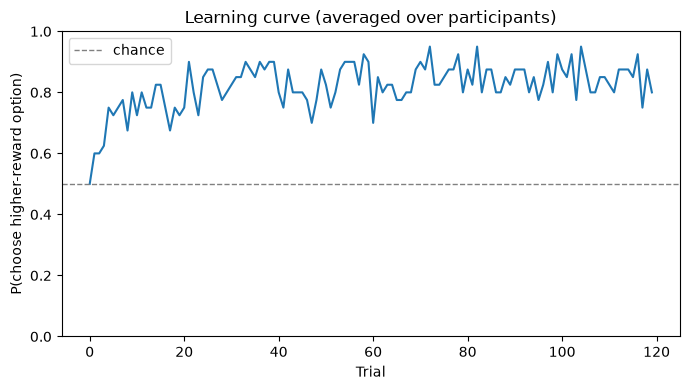

In [10]:
# Proportion choosing the higher-reward option (response == -1), averaged across
# participants at each trial.
data = data.copy()
data["chose_high_reward"] = (data["response"] == -1).astype(float)
learning_curve = data.groupby("trial_id")["chose_high_reward"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(learning_curve.index, learning_curve.values, color="C0")
ax.axhline(0.5, ls="--", color="gray", lw=1, label="chance")
ax.set_xlabel("Trial")
ax.set_ylabel("P(choose higher-reward option)")
ax.set_title("Learning curve (averaged over participants)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

The curve climbs well above chance — the agents are learning. But the learning curve
only shows choices. To see the RLSSM connection more directly, we can replay one
participant's history and compute the hidden Q-value difference and drift rate used on
each trial.


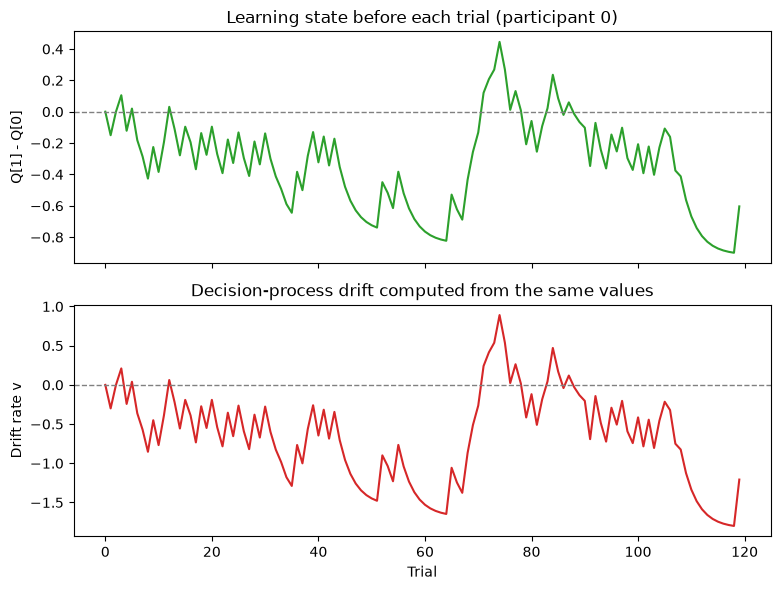

In [11]:
participant_history = data.loc[
    data["participant_id"] == 0, ["trial_id", "response", "feedback"]
].reset_index(drop=True)

replay_learner = rl.learning.RescorlaWagnerDrift(n_actions=2, initial_q=0.5)
replay_state = replay_learner.init_state()
rl_params = {"rl_alpha": theta["rl_alpha"], "scaler": theta["scaler"]}

trajectory_rows = []
for trial in participant_history.itertuples(index=False):
    choice = config.response_to_choice[int(trial.response)]
    context = {
        "response": int(trial.response),
        "choice": choice,
        "feedback": float(trial.feedback),
    }
    computed = replay_learner.compute_python(replay_state, rl_params, context)
    q_values = replay_state["q_values"].copy()

    trajectory_rows.append(
        {
            "trial_id": int(trial.trial_id),
            "q_0": q_values[0],
            "q_1": q_values[1],
            "q_diff": q_values[1] - q_values[0],
            "drift": computed["v"],
            "response": int(trial.response),
            "feedback": float(trial.feedback),
            "choice": choice,
        }
    )
    replay_state = replay_learner.update_python(replay_state, rl_params, context)

trajectory = pd.DataFrame(trajectory_rows)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(trajectory["trial_id"], trajectory["q_diff"], color="C2")
axes[0].axhline(0, ls="--", color="gray", lw=1)
axes[0].set_ylabel("Q[1] - Q[0]")
axes[0].set_title("Learning state before each trial (participant 0)")

axes[1].plot(trajectory["trial_id"], trajectory["drift"], color="C3")
axes[1].axhline(0, ls="--", color="gray", lw=1)
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Drift rate v")
axes[1].set_title("Decision-process drift computed from the same values")

plt.tight_layout()
plt.show()

The two panels have the same shape because this model uses a simple link:

```python
v = (Q[1] - Q[0]) * scaler
```

That link is the bridge between the learning process and the decision process. The
learning rule does not directly choose for the agent; instead, it changes the drift rate
that the SSM uses to generate a choice and RT. When `Q[1] - Q[0]` is negative, drift
favors the response associated with arm 0 (`-1` here). When it is positive, drift favors
arm 1 (`1`).

Next, we look at the RT distribution, split by which option was chosen.


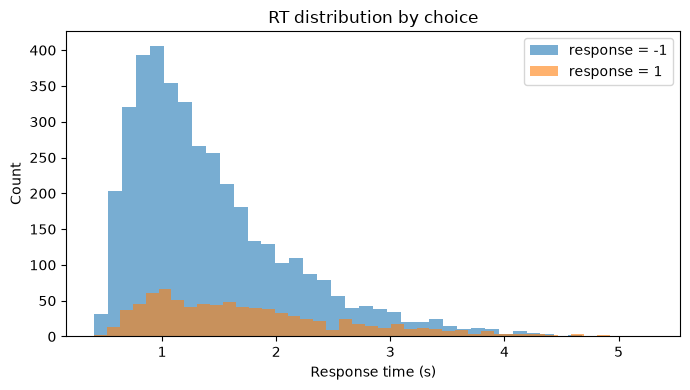

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, color in [(-1, "C0"), (1, "C1")]:
    rts = data.loc[data["response"] == label, "rt"]
    ax.hist(rts, bins=40, alpha=0.6, color=color, label=f"response = {label}")
ax.set_xlabel("Response time (s)")
ax.set_ylabel("Count")
ax.set_title("RT distribution by choice")
ax.legend()
plt.tight_layout()
plt.show()

## 7. From simulation to inference

The point of simulating data is usually to *test inference* — can a model recover the
parameters that generated the data? That is HSSM's job. Two small steps connect the two
packages: **validating** the data, and **handing it off**.

Validation is worth doing even for simulated data because it catches mismatches that are
easy to miss: a renamed feedback column, invalid response labels, missing RTs, or rows
that are no longer ordered by participant and trial.


### Validate the data

Before inference, it helps to check that a dataset has the structure HSSM expects
(required columns, a balanced and trial-ordered panel, valid response labels, no
stray missing values). `config.validate_data(...)` does this and returns a report you
can print, or turn into an error if something is wrong.

In [13]:
report = config.validate_data(data)
report.print()

# In a script you would typically guard with:
#   report.raise_for_errors()   # raises if the data is not inference-ready

RLSSM data validation report:
  [WARNING] extra_columns: data has extra columns not required by this model: ['chose_high_reward', 'trial_id'].
  panel shape: participants=40, trials_per_participant=120


### Hand off to HSSM

HSSM consumes an `ssms.rl` model through a small **bridge**. The simulator side exposes
the model's structure as a plain dictionary, which is a useful thing to inspect. In the
Milestone 4 contract, observable task/design columns are called `context_fields`, and
the participant contract shows the exact participant-history columns used to replay
learning during inference:


In [14]:
bridge_dict = config.to_hssm_config_dict()

print("model_name      :", bridge_dict["model_name"])
print("decision_process:", bridge_dict["decision_process"])
print("list_params     :", bridge_dict["list_params"])
print("context_fields  :", bridge_dict["context_fields"])
print("computed_outputs:", bridge_dict["participant_contract"]["computed_outputs"])
print("input_fields    :", bridge_dict["participant_contract"]["input_fields"])

model_name      : 2AB_RW_Angle
decision_process: angle
list_params     : ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']
context_fields  : ['feedback']
computed_outputs: ['v']
input_fields    : ['rl_alpha', 'scaler', 'response', 'feedback']


On the HSSM side, you don't assemble any of this by hand. HSSM provides a factory that
takes the `ssms.rl` model (by preset name or config object), assembles the simulator-side
participant function with the JAX backend, and builds a ready-to-fit HSSM config. The
code below is **illustrative** — it requires HSSM to be installed and is not run as part
of this simulator tutorial:

```python
import hssm

# Build an HSSM model directly from the ssms.rl model.
hssm_config = hssm.rl.RLSSMConfig.from_ssms_model(config)   # or "2AB_RW_Angle"
model = hssm.RLSSM(data=data, model_config=hssm_config)

# ... then sample and inspect as usual:
# idata = model.sample()
```

Internally, HSSM carries `ssms.rl` `context_fields` through its RLSSM data-column
plumbing and uses the assembled participant function to compute every trial-wise SSM
parameter declared by the simulator model. A higher-level constructor —
`hssm.RLSSM(data, model="2AB_RW_Angle")` — is planned but not yet available, so for now
use `RLSSMConfig.from_ssms_model(...)`. For the full end-to-end inference and
parameter-recovery workflow, see the [`ssms.rl` API reference](../api/rlssm.md).


## 8. Summary and next steps

You now know the whole basic arc:

- An **RLSSM** = a **learning process** + a **decision process (SSM)** + a **task
  environment**, simulated in an interleaved trial-by-trial loop.
- The learning process updates Q-values from feedback; the decision process turns the
  current value state into choice and RT.
- In the preset model, `Q[1] - Q[0]` is scaled into the trial-wise drift rate `v`, which
  is why plotting Q-value differences and drift helps diagnose whether learning is
  informing the decision process as intended.
- More general `ssms.rl` models can compute other trial-wise decision parameters too;
  the advanced tutorial shows that handshake explicitly.
- **Presets** (`rl.preset.list / info / get`) are the fastest way to a working model.
- A **`ModelConfig`** can be built by hand from the three pillars; `rl.Simulator`
  turns it (plus a `theta` of parameter values) into a balanced panel of behavioral
  data, for one or many participants.
- The data is a tidy DataFrame you can inspect, plot, **validate**, and **hand off to
  HSSM** for inference.

Other useful beginner exercises:

- Change `rl_alpha` and watch how quickly the learning curve moves away from chance.
- Change `scaler` and watch how strongly the same Q-value difference affects drift and
  RTs.
- Simulate a few participant-wise `rl_alpha` values and compare their learning curves.
- Use `config.validate_data(...)` on a deliberately edited dataset to see the repair
  hints.

**Continue with the [advanced tutorial](rlssm_advanced_tutorial.ipynb)**, which covers:

- response labels vs. zero-based learning choices, and explicit `response_to_choice`;
- alternative components: dual-learning-rate Rescorla-Wagner, Gaussian-reward bandits,
  the `TaskConfig` shorthand, and custom task/learning components;
- context-aware learning with task/design columns such as `condition`;
- full participant-wise theta rules;
- posterior predictive simulation with `mode="ppc"`;
- validation failure modes;
- assembled models, multi-output computed parameters, and the HSSM bridge internals.
